In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [1]:
import os
import pandas as pd

# Pfadangaben aktualisieren
main_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/Analysis_Data_Final_STOXX600'
excel_path = "/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/Stoxx_600_Full.xlsx"
company_info_df = pd.read_excel(excel_path)

# Liste zur Speicherung der DataFrames aus jedem Subordner
df_list = []

# Zähler für die Unternehmen
company_no = 1

# Durchlaufen jedes Subordners
for subfolder in sorted(os.listdir(main_path)):
    subfolder_path = os.path.join(main_path, subfolder)
    if os.path.isdir(subfolder_path):
        all_files = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path) if f.endswith('.csv')]
        
        for file in all_files:
            practice_df = pd.read_csv(file)
            practice_df['date'] = pd.to_datetime(practice_df['date'])
            practice_df['practice'] = os.path.basename(file).split('.')[0]
            practice_df['subfolder_name'] = subfolder
            # Füge die Unternehmensnummer zum DataFrame hinzu
            practice_df['Company No'] = company_no
            df_list.append(practice_df)
        
        # Zähler nach der Verarbeitung jedes Subfolders inkrementieren
        company_no += 1

# Zusammenführen aller DataFrames
df = pd.concat(df_list)
df.sort_values(by=['practice', 'date'], inplace=True)

# Verknüpfung mit company_info_df, um Unternehmensnamen und Supersektor hinzuzufügen
df = df.merge(company_info_df, left_on='subfolder_name', right_on='Subfolder Name', how='left')


In [2]:
df.to_csv("startdfV1.csv")

In [4]:
df.size

1535699200

In [ ]:
import os
import pandas as pd

# Pfad zum Ordner mit den Volumendaten
volume_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/volumes'

# Liste für die gesammelten Daten
data_list = []

# Initialisiere den Unternehmenszähler
company_no = 1

# Durchlaufe alle Dateien im angegebenen Verzeichnis
for file_name in sorted(os.listdir(volume_path)):
    if file_name.endswith('.csv'):
        # Extrahiere den Unternehmensnamen aus dem Dateinamen (ohne ".csv")
        company_name = file_name[:-4]
        
        # Vollständiger Pfad zur CSV-Datei
        file_path = os.path.join(volume_path, file_name)
        
        # Lade die CSV-Datei
        df_2 = pd.read_csv(file_path)
        
        # Umwandeln der 'date'-Spalte in ein Datumsformat
        df_2['date'] = pd.to_datetime(df['date'])
        df_2.set_index('date', inplace=True)
        
        # Aggregiere die Volumendaten auf Monatsbasis
        monthly_volume = df_2['volume'].resample('M').sum()
        
        # Erstelle einen DataFrame aus den aggregierten Daten
        monthly_volume_df = pd.DataFrame(monthly_volume, columns=['volume'])
        monthly_volume_df['company'] = company_name
        
        # Füge die Unternehmensnummer zum DataFrame hinzu
        monthly_volume_df['Company No'] = company_no
        
        # Füge den DataFrame zur Liste hinzu
        data_list.append(monthly_volume_df)
        
        # Inkrementiere den Unternehmenszähler
        company_no += 1

# Kombiniere alle DataFrames in der Liste zu einem einzigen DataFrame
combined_df = pd.concat(data_list).reset_index()

# Sortiere den DataFrame nach Unternehmen und Datum
combined_df.sort_values(by=['company', 'date'], inplace=True)

combined_df


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_12008/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_12008/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_12008/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_12008/2711809087.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df_2['volume'].resample('M').sum()
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykern

,date,volume,company,Company No
0,2021-01-31,4313,3i,1
1,2021-01-31,954,a2a,2
2,2021-01-31,7096,aak_ab,3
3,2021-01-31,1117,aalberts_industries,4
4,2021-01-31,14084,ab_electrolux,5
...,...,...,...,...
585,2021-01-31,9841,worldline_sa,586
586,2021-01-31,65210,wpp,587
587,2021-01-31,43277,yara_international,588
588,2021-01-31,181415,zalando,589


In [5]:
combined_df.to_csv("combinedsicherungV1.csv")

In [3]:
combined_df = pd.read_csv("combinedsicherungV1.csv")
df = pd.read_csv("startdfV1.csv")

In [4]:
combined_df.set_index("company")

,Unnamed: 0,date,volume,Company No
company,,,,
3i,0,2021-01-31,4313,1
a2a,1,2021-01-31,954,2
aak_ab,2,2021-01-31,7096,3
aalberts_industries,3,2021-01-31,1117,4
ab_electrolux,4,2021-01-31,14084,5
...,...,...,...,...
worldline_sa,585,2021-01-31,9841,586
wpp,586,2021-01-31,65210,587
yara_international,587,2021-01-31,43277,588


In [5]:
# Dein bestehender DataFrame
# Stelle sicher, dass 'combined_df' bereits existiert und eine 'date' Spalte hat
combined_df["date"] = pd.to_datetime(combined_df["date"])

# Erstelle die year_month Spalte
combined_df["year_month"] = combined_df["date"].dt.to_period("M")

# Berechne das maximale Volumen pro Monat und die dazugehörige Firma
max_volume_per_month = combined_df.loc[combined_df.groupby("year_month")["volume"].idxmax(), ["year_month", "volume", "company"]]

# Umbenennen der Spalten für Klarheit
max_volume_per_month.rename(columns={"volume": "max_volume_per_month", "company": "max_volume_company"}, inplace=True)

# Mergen mit dem ursprünglichen DataFrame
combined_df = combined_df.merge(max_volume_per_month, on="year_month", how="left")

# Ergebnis anzeigen
print(combined_df.head())

   Unnamed: 0       date  volume              company  Company No year_month  \
0           0 2021-01-31    4313                   3i           1    2021-01   
1           1 2021-01-31     954                  a2a           2    2021-01   
2           2 2021-01-31    7096               aak_ab           3    2021-01   
3           3 2021-01-31    1117  aalberts_industries           4    2021-01   
4           4 2021-01-31   14084        ab_electrolux           5    2021-01   

   max_volume_per_month max_volume_company  
0               3225817        astrazeneca  
1               3225817        astrazeneca  
2               3225817        astrazeneca  
3               3225817        astrazeneca  
4               3225817        astrazeneca  


In [6]:
combined_df.head()

,Unnamed: 0,date,volume,company,Company No,year_month,max_volume_per_month,max_volume_company
0,0,2021-01-31,4313,3i,1,2021-01,3225817,astrazeneca
1,1,2021-01-31,954,a2a,2,2021-01,3225817,astrazeneca
2,2,2021-01-31,7096,aak_ab,3,2021-01,3225817,astrazeneca
3,3,2021-01-31,1117,aalberts_industries,4,2021-01,3225817,astrazeneca
4,4,2021-01-31,14084,ab_electrolux,5,2021-01,3225817,astrazeneca


In [7]:
combined_df.tail()

,Unnamed: 0,date,volume,company,Company No,year_month,max_volume_per_month,max_volume_company
585,585,2021-01-31,9841,worldline_sa,586,2021-01,3225817,astrazeneca
586,586,2021-01-31,65210,wpp,587,2021-01,3225817,astrazeneca
587,587,2021-01-31,43277,yara_international,588,2021-01,3225817,astrazeneca
588,588,2021-01-31,181415,zalando,589,2021-01,3225817,astrazeneca
589,589,2021-01-31,115524,zurich_insurance,590,2021-01,3225817,astrazeneca


In [8]:
combined_df.rename(columns={"max_volume_per_month": "max_volume"}, inplace=True)

In [9]:
# Stellen Sie sicher, dass 'year_month' eine Spalte im max_volume_per_month DataFrame ist
max_volume_per_month.reset_index(inplace=True, drop=True)

# Umbenennen der Spalten für Klarheit
max_volume_per_month.rename(columns={'volume': 'max_volume', 'company': 'max_volume_company'}, inplace=True)

# Sicherstellen, dass 'year_month' im combined_df als Spalte vorhanden ist
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# Merge-Operation durchführen
# Da jetzt beide DataFrames 'year_month' als normale Spalte behandeln, sollte der Merge funktionieren
combined_df = pd.merge(combined_df, max_volume_per_month, on='year_month', how='left')

# Optional: Entfernen der 'year_month' Spalte, wenn sie nicht mehr benötigt wird
combined_df.drop('year_month', inplace=True, axis=1)

combined_df


,Unnamed: 0,date,volume,company,Company No,max_volume,max_volume_company_x,max_volume_per_month,max_volume_company_y
0,0,2021-01-31,4313,3i,1,3225817,astrazeneca,3225817,astrazeneca
1,1,2021-01-31,954,a2a,2,3225817,astrazeneca,3225817,astrazeneca
2,2,2021-01-31,7096,aak_ab,3,3225817,astrazeneca,3225817,astrazeneca
3,3,2021-01-31,1117,aalberts_industries,4,3225817,astrazeneca,3225817,astrazeneca
4,4,2021-01-31,14084,ab_electrolux,5,3225817,astrazeneca,3225817,astrazeneca
...,...,...,...,...,...,...,...,...,...
585,585,2021-01-31,9841,worldline_sa,586,3225817,astrazeneca,3225817,astrazeneca
586,586,2021-01-31,65210,wpp,587,3225817,astrazeneca,3225817,astrazeneca
587,587,2021-01-31,43277,yara_international,588,3225817,astrazeneca,3225817,astrazeneca
588,588,2021-01-31,181415,zalando,589,3225817,astrazeneca,3225817,astrazeneca


In [10]:
combined_df = combined_df.sort_values(by='company')

In [11]:
combined_df.head()

,Unnamed: 0,date,volume,company,Company No,max_volume,max_volume_company_x,max_volume_per_month,max_volume_company_y
0,0,2021-01-31,4313,3i,1,3225817,astrazeneca,3225817,astrazeneca
1,1,2021-01-31,954,a2a,2,3225817,astrazeneca,3225817,astrazeneca
2,2,2021-01-31,7096,aak_ab,3,3225817,astrazeneca,3225817,astrazeneca
3,3,2021-01-31,1117,aalberts_industries,4,3225817,astrazeneca,3225817,astrazeneca
4,4,2021-01-31,14084,ab_electrolux,5,3225817,astrazeneca,3225817,astrazeneca


In [12]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            590 non-null    int64         
 1   date                  590 non-null    datetime64[ns]
 2   volume                590 non-null    int64         
 3   company               590 non-null    object        
 4   Company No            590 non-null    int64         
 5   max_volume            590 non-null    int64         
 6   max_volume_company_x  590 non-null    object        
 7   max_volume_per_month  590 non-null    int64         
 8   max_volume_company_y  590 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 41.6+ KB


In [13]:
import numpy as np

# Berechnung der 'weight' Spalte mit logarithmischer Transformation
combined_df['log_weight'] = np.log(combined_df['max_volume']) - np.log(combined_df['volume'])

# Behandle Division durch Null oder Fälle, wo das Volumen 0 ist, um Unendlichkeiten oder NaNs zu vermeiden
combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)

combined_df


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_18831/1212500697.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)


,Unnamed: 0,date,volume,company,Company No,max_volume,max_volume_company_x,max_volume_per_month,max_volume_company_y,log_weight
0,0,2021-01-31,4313,3i,1,3225817,astrazeneca,3225817,astrazeneca,6.617308
1,1,2021-01-31,954,a2a,2,3225817,astrazeneca,3225817,astrazeneca,8.126033
2,2,2021-01-31,7096,aak_ab,3,3225817,astrazeneca,3225817,astrazeneca,6.119410
3,3,2021-01-31,1117,aalberts_industries,4,3225817,astrazeneca,3225817,astrazeneca,7.968295
4,4,2021-01-31,14084,ab_electrolux,5,3225817,astrazeneca,3225817,astrazeneca,5.433902
...,...,...,...,...,...,...,...,...,...,...
585,585,2021-01-31,9841,worldline_sa,586,3225817,astrazeneca,3225817,astrazeneca,5.792384
586,586,2021-01-31,65210,wpp,587,3225817,astrazeneca,3225817,astrazeneca,3.901329
587,587,2021-01-31,43277,yara_international,588,3225817,astrazeneca,3225817,astrazeneca,4.311320
588,588,2021-01-31,181415,zalando,589,3225817,astrazeneca,3225817,astrazeneca,2.878154


In [14]:
df.head()

,Unnamed: 0.1,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Company No,Subfolder Name,Supersector,Company Name Full
0,0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,1,3i_III_GB00B1YW4409,Financial Services,3I GRP
1,1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,2,a2a_A2A_IT0001233417,Utilities,A2A
2,2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,3,aak_ab_AAK_SE0011337708,Food & Beverage,AAK
3,3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,4,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,AALBERTS INDUSTRIES
4,4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,5,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,SABMILLER


In [15]:
# Function to extract 'capability' from the 'practice' column
def extract_capability(practice):
    parts = practice.split('-')
    if len(parts) > 2:
        return parts[1][:3]  # Extract the first 2-3 letters of the second part
    else:
        return 'Unknown'

# Function to extract 'pillar' from the 'practice' column
def extract_pillar(practice):
    parts = practice.split('-')
    return parts[0][:3]  # Extract the first 2-3 letters of the first part

# Apply these functions to create the new columns
df['capability'] = df['practice'].apply(extract_capability)
df['pillar'] = df['practice'].apply(extract_pillar)

df.head()

,Unnamed: 0.1,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Company No,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,1,3i_III_GB00B1YW4409,Financial Services,3I GRP,CCF,BMI
1,1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,2,a2a_A2A_IT0001233417,Utilities,A2A,CCF,BMI
2,2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,3,aak_ab_AAK_SE0011337708,Food & Beverage,AAK,CCF,BMI
3,3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,4,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,AALBERTS INDUSTRIES,CCF,BMI
4,4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,5,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,SABMILLER,CCF,BMI


In [16]:
# Datentypen optimieren, z.B. für 'Company No'
df['Company No'] = df['Company No'].astype('category')
combined_df['Company No'] = combined_df['Company No'].astype('int32') # Angenommen, dies ist der geeignete Typ

# Datum nur einmal umwandeln und Jahr-Monat extrahieren
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# Spalten vor dem Merge filtern, um den Speicherverbrauch zu reduzieren
df_filtered = df[['Company No', 'year_month', 'Company Name Full', 'date', 'volume',	'practice',	'subfolder_name',	'Subfolder Name',	'Supersector',	'capability',	'pillar']] # und andere notwendige Spalten
combined_df_filtered = combined_df[['Company No', 'year_month', 'log_weight']]

# Merge durchführen
df_merged_volume = pd.merge(df_filtered, combined_df_filtered, on=['Company No', 'year_month'], how='left')

# Ergebnis überprüfen
df_merged_volume.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109692800 entries, 0 to 109692799
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Company No         int64         
 1   year_month         period[M]     
 2   Company Name Full  object        
 3   date               datetime64[ns]
 4   volume             int64         
 5   practice           object        
 6   subfolder_name     object        
 7   Subfolder Name     object        
 8   Supersector        object        
 9   capability         object        
 10  pillar             object        
 11  log_weight         float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(7), period[M](1)
memory usage: 9.8+ GB


In [17]:
df_merged_volume.head(1185)
df = df_merged_volume

In [18]:
df.head()

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,log_weight
0,1,2021-01,3I GRP,2021-01-01,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,3i_III_GB00B1YW4409,Financial Services,CCF,BMI,6.617308
1,2,2021-01,A2A,2021-01-01,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,a2a_A2A_IT0001233417,Utilities,CCF,BMI,8.126033
2,3,2021-01,AAK,2021-01-01,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,aak_ab_AAK_SE0011337708,Food & Beverage,CCF,BMI,6.119410
3,4,2021-01,AALBERTS INDUSTRIES,2021-01-01,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,CCF,BMI,7.968295
4,5,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,CCF,BMI,5.433902


In [19]:
# Replace 'PA0' with 'PAO' in the 'pillar' column
df['pillar'] = df['pillar'].replace('PA0', 'PAO')

# Verify the replacement
print(df['pillar'].unique())


['BMI' 'CE' 'CSE' 'CSG' 'DA' 'DLC' 'DST' 'PAO' 'TI']


In [20]:
df.head()

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,log_weight
0,1,2021-01,3I GRP,2021-01-01,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,3i_III_GB00B1YW4409,Financial Services,CCF,BMI,6.617308
1,2,2021-01,A2A,2021-01-01,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,a2a_A2A_IT0001233417,Utilities,CCF,BMI,8.126033
2,3,2021-01,AAK,2021-01-01,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,aak_ab_AAK_SE0011337708,Food & Beverage,CCF,BMI,6.119410
3,4,2021-01,AALBERTS INDUSTRIES,2021-01-01,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,CCF,BMI,7.968295
4,5,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,CCF,BMI,5.433902


In [21]:
df["volume_weighted"] = df["volume"] * df["log_weight"]

In [22]:
df.head(7)

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,log_weight,volume_weighted
0,1,2021-01,3I GRP,2021-01-01,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,3i_III_GB00B1YW4409,Financial Services,CCF,BMI,6.617308,0.0
1,2,2021-01,A2A,2021-01-01,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,a2a_A2A_IT0001233417,Utilities,CCF,BMI,8.126033,0.0
2,3,2021-01,AAK,2021-01-01,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,aak_ab_AAK_SE0011337708,Food & Beverage,CCF,BMI,6.119410,0.0
3,4,2021-01,AALBERTS INDUSTRIES,2021-01-01,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,CCF,BMI,7.968295,0.0
4,5,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,CCF,BMI,5.433902,0.0
5,6,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_sagax_SAGA B_SE0005127818,ab_sagax_SAGA B_SE0005127818,Food & Beverage,CCF,BMI,5.503661,0.0
6,7,2021-01,ABB,2021-01-01,0,BMI-CCF-Capability Focus,abb_ABBN_CH0012221716,abb_ABBN_CH0012221716,Industrial Goods & Services,CCF,BMI,2.787966,0.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109692800 entries, 0 to 109692799
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Company No         int64         
 1   year_month         period[M]     
 2   Company Name Full  object        
 3   date               datetime64[ns]
 4   volume             int64         
 5   practice           object        
 6   subfolder_name     object        
 7   Subfolder Name     object        
 8   Supersector        object        
 9   capability         object        
 10  pillar             object        
 11  log_weight         float64       
 12  volume_weighted    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7), period[M](1)
memory usage: 10.6+ GB


In [24]:
# Convert 'date' to datetime, handling errors
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert 'date' to a monthly period
df['month'] = df['date'].dt.to_period('M')

In [25]:
df.to_csv("df-zwischensaveV20250506.csv")

KeyboardInterrupt: 

In [26]:
cumulative_volume_per_month = df.groupby(['practice', 'Company Name Full', 'month', 'Supersector', 'capability', 'pillar'])['volume_weighted'].sum().reset_index()

# Rename the 'volume' column to 'cumulative_volume_per_month' for clarity
cumulative_volume_per_month.rename(columns={'volume_weighted': 'cumulative_volume_per_month'}, inplace=True)

In [27]:
cumulative_volume_per_month.head()

,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month
0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0
1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0
2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0
3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0
4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0


Monatliche Score Erstellung von 1-10 basiernd auf Verteilung des Volumes innerhalb des gleichen Sektors pro Practice

In [28]:
# Define the function to assign scores
def assign_score(volume, percentiles):
    if volume == 0:
        return 0
    for i in range(10, 0, -1):  # Start from the highest percentile
        if volume > percentiles.get(f'p{i*10}', np.inf):
            return i
    return 1  # If the volume is not greater than any percentile, return the lowest score

# Calculate percentiles for each group
def calculate_percentiles(group):
    percentiles = np.percentile(group['cumulative_volume_per_month'], [10 * i for i in range(1, 11)])
    return pd.Series(percentiles, index=[f'p{10 * i}' for i in range(1, 11)])

# Apply the function to calculate percentiles for each 'practice', 'Supersector', and 'month' combination
percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()

# Merge the percentiles back into the original DataFrame
merged_df = pd.merge(cumulative_volume_per_month, percentile_df, on=['practice', 'Supersector', 'month'])

# Assign scores using the percentiles
merged_df['score'] = merged_df.apply(lambda row: assign_score(row['cumulative_volume_per_month'], row.to_dict()), axis=1)

# Debugging: Print the percentiles and scores for a specific practice and supersector in a specific month
debug_df = merged_df[(merged_df['practice'] == 'example_practice') & (merged_df['Supersector'] == 'example_supersector') & (merged_df['month'] == 'example_month')]
print(debug_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100']])

print(merged_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score']])


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_18831/3988397357.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()


Empty DataFrame
Columns: [practice, Supersector, month, cumulative_volume_per_month, score, p10, p20, p30, p40, p50, p60, p70, p80, p90, p100]
Index: []
                                 practice         Supersector    month  \
0                BMI-CCF-Capability Focus  Financial Services  2021-01   
1                BMI-CCF-Capability Focus  Financial Services  2021-02   
2                BMI-CCF-Capability Focus  Financial Services  2021-03   
3                BMI-CCF-Capability Focus  Financial Services  2021-04   
4                BMI-CCF-Capability Focus  Financial Services  2021-05   
...                                   ...                 ...      ...   
3261397  TI-SDH-Data Storage Optimization         Real Estate  2023-09   
3261398  TI-SDH-Data Storage Optimization         Real Estate  2023-10   
3261399  TI-SDH-Data Storage Optimization         Real Estate  2023-11   
3261400  TI-SDH-Data Storage Optimization         Real Estate  2023-12   
3261401  TI-SDH-Data Storage Opti

In [29]:
merged_df.head(145000)

,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144995,BMI-EC-Ecosystem Growth,GJENSIDIGE FORSIKRING,2023-06,Insurance,EC,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
144996,BMI-EC-Ecosystem Growth,GJENSIDIGE FORSIKRING,2023-07,Insurance,EC,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
144997,BMI-EC-Ecosystem Growth,GJENSIDIGE FORSIKRING,2023-08,Insurance,EC,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
144998,BMI-EC-Ecosystem Growth,GJENSIDIGE FORSIKRING,2023-09,Insurance,EC,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [30]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3261402 entries, 0 to 3261401
Data columns (total 18 columns):
 #   Column                       Dtype    
---  ------                       -----    
 0   practice                     object   
 1   Company Name Full            object   
 2   month                        period[M]
 3   Supersector                  object   
 4   capability                   object   
 5   pillar                       object   
 6   cumulative_volume_per_month  float64  
 7   p10                          float64  
 8   p20                          float64  
 9   p30                          float64  
 10  p40                          float64  
 11  p50                          float64  
 12  p60                          float64  
 13  p70                          float64  
 14  p80                          float64  
 15  p90                          float64  
 16  p100                         float64  
 17  score                        int64    
dtypes:

In [31]:
merged_df2 = merged_df

# Benchmark Teil 1

In [52]:
merged_df2 = pd.read_csv("/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv")

In [59]:
merged_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3255260 entries, 0 to 3255259
Data columns (total 19 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   practice                     object 
 2   Company Name Full            object 
 3   month                        object 
 4   Supersector                  object 
 5   capability                   object 
 6   pillar                       object 
 7   cumulative_volume_per_month  float64
 8   p10                          float64
 9   p20                          float64
 10  p30                          float64
 11  p40                          float64
 12  p50                          float64
 13  p60                          float64
 14  p70                          float64
 15  p80                          float64
 16  p90                          float64
 17  p100                         float64
 18  score                        int64  
dtype

In [60]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3261402 entries, 0 to 3261401
Data columns (total 18 columns):
 #   Column                       Dtype    
---  ------                       -----    
 0   practice                     object   
 1   Company Name Full            object   
 2   month                        period[M]
 3   Supersector                  object   
 4   capability                   object   
 5   pillar                       object   
 6   cumulative_volume_per_month  float64  
 7   p10                          float64  
 8   p20                          float64  
 9   p30                          float64  
 10  p40                          float64  
 11  p50                          float64  
 12  p60                          float64  
 13  p70                          float64  
 14  p80                          float64  
 15  p90                          float64  
 16  p100                         float64  
 17  score                        int64    
dtypes:

In [33]:
#test merged2

# Calculate the maximum possible score for each capability
max_scores_per_capability = merged_df2.groupby('capability').agg({'practice': 'nunique'}).reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# Sum the scores for each company, capability, supersector, pillar, and month
capability_scores = merged_df2.groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'month'])['score'].sum().reset_index()

# Rename the 'score' column to 'maturity_score' for clarity
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# Merge the maximum scores for each capability back into the capability_scores DataFrame
final_scores2 = pd.merge(capability_scores, max_scores_per_capability[['capability', 'max_score_per_capability']], on='capability', how='left')

# Select relevant columns for display
final_scores2 = final_scores2[['Company Name Full', 'capability', 'Supersector', 'pillar', 'month', 'maturity_score', 'max_score_per_capability']]

final_scores2.head()




,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,3I GRP,AID,Financial Services,TI,2021-01,0,60
1,3I GRP,AID,Financial Services,TI,2021-02,0,60
2,3I GRP,AID,Financial Services,TI,2021-03,0,60
3,3I GRP,AID,Financial Services,TI,2021-04,0,60
4,3I GRP,AID,Financial Services,TI,2021-05,0,60


In [34]:
final_scores2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609057 entries, 0 to 609056
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype    
---  ------                    --------------   -----    
 0   Company Name Full         609057 non-null  object   
 1   capability                609057 non-null  object   
 2   Supersector               609057 non-null  object   
 3   pillar                    609057 non-null  object   
 4   month                     609057 non-null  period[M]
 5   maturity_score            609057 non-null  int64    
 6   max_score_per_capability  609057 non-null  int64    
dtypes: int64(2), object(4), period[M](1)
memory usage: 32.5+ MB


In [67]:
final_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607910 entries, 0 to 607909
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Company Name Full         607910 non-null  object
 1   capability                607910 non-null  object
 2   Supersector               607910 non-null  object
 3   pillar                    607910 non-null  object
 4   month                     607910 non-null  object
 5   maturity_score            607910 non-null  int64 
 6   max_score_per_capability  607910 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 32.5+ MB


In [56]:
# Calculate the maximum possible score for each capability
max_scores_per_capability = merged_df.groupby('capability').agg({'practice': 'nunique'}).reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# Sum the scores for each company, capability, supersector, pillar, and month
capability_scores = merged_df.groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'month'])['score'].sum().reset_index()

# Rename the 'score' column to 'maturity_score' for clarity
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# Merge the maximum scores for each capability back into the capability_scores DataFrame
final_scores = pd.merge(capability_scores, max_scores_per_capability[['capability', 'max_score_per_capability']], on='capability', how='left')

# Select relevant columns for display
final_scores = final_scores[['Company Name Full', 'capability', 'Supersector', 'pillar', 'month', 'maturity_score', 'max_score_per_capability']]

final_scores.head()




,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,3I GRP,AID,Financial Services,TI,2021-01,0,60
1,3I GRP,AID,Financial Services,TI,2021-02,0,60
2,3I GRP,AID,Financial Services,TI,2021-03,0,60
3,3I GRP,AID,Financial Services,TI,2021-04,0,60
4,3I GRP,AID,Financial Services,TI,2021-05,0,60


In [58]:
final_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609057 entries, 0 to 609056
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype    
---  ------                    --------------   -----    
 0   Company Name Full         609057 non-null  object   
 1   capability                609057 non-null  object   
 2   Supersector               609057 non-null  object   
 3   pillar                    609057 non-null  object   
 4   month                     609057 non-null  period[M]
 5   maturity_score            609057 non-null  int64    
 6   max_score_per_capability  609057 non-null  int64    
dtypes: int64(2), object(4), period[M](1)
memory usage: 32.5+ MB


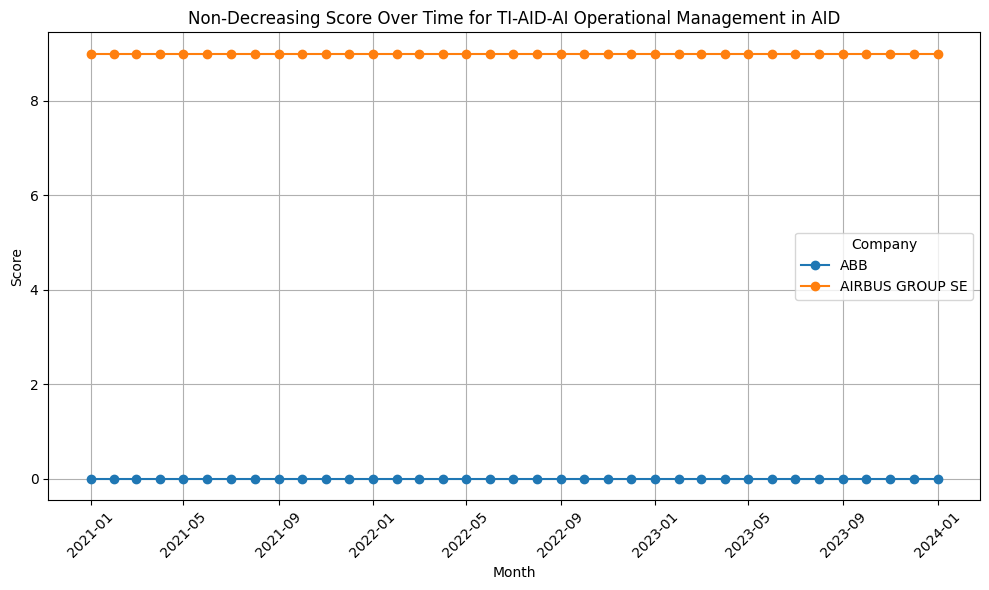

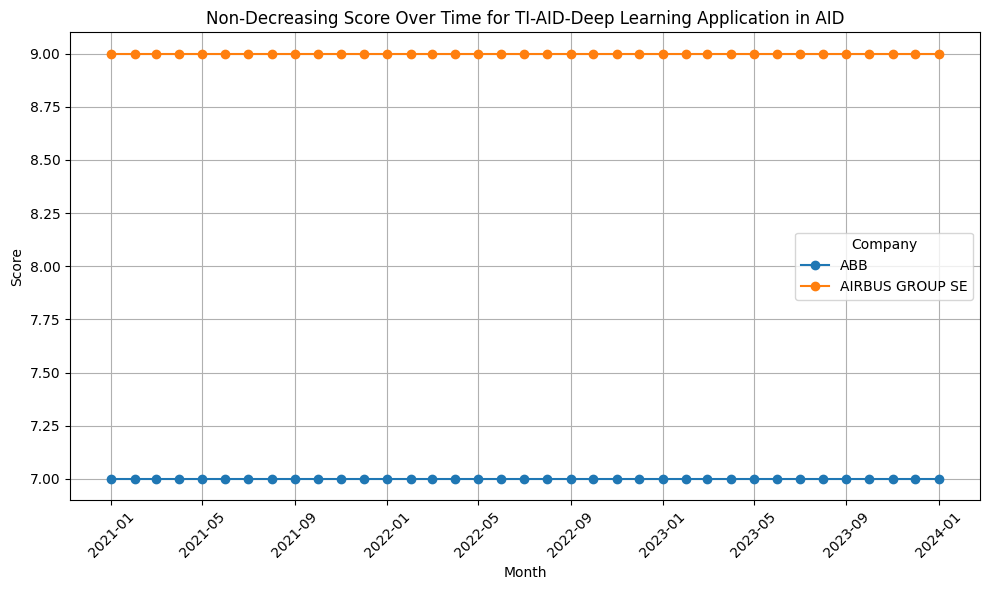

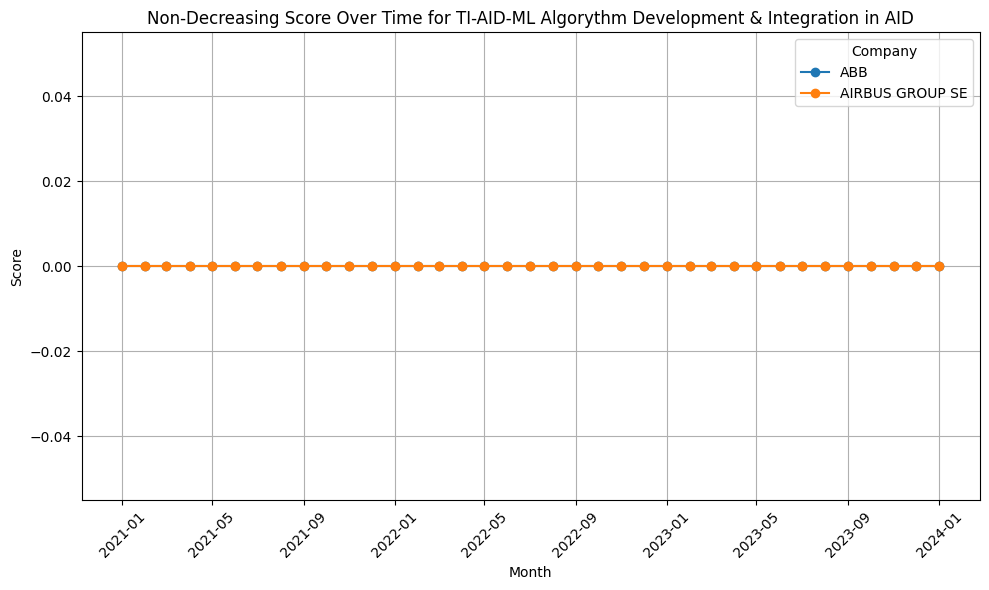

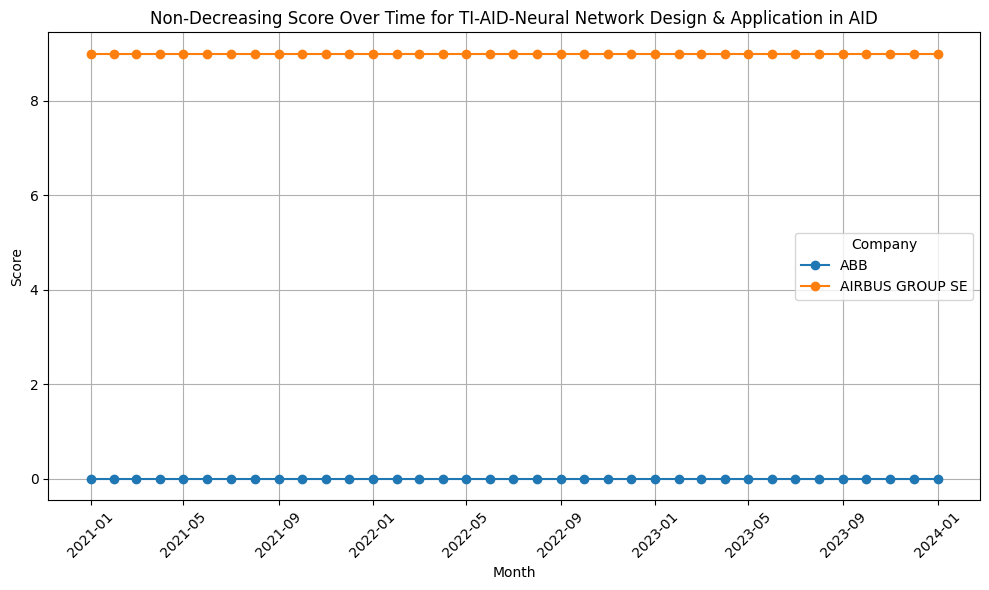

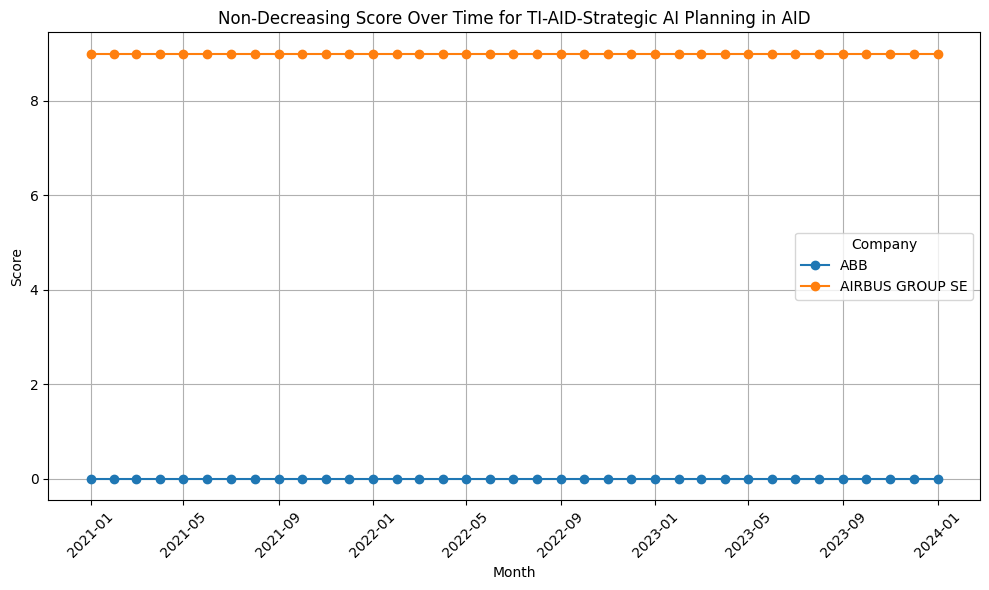

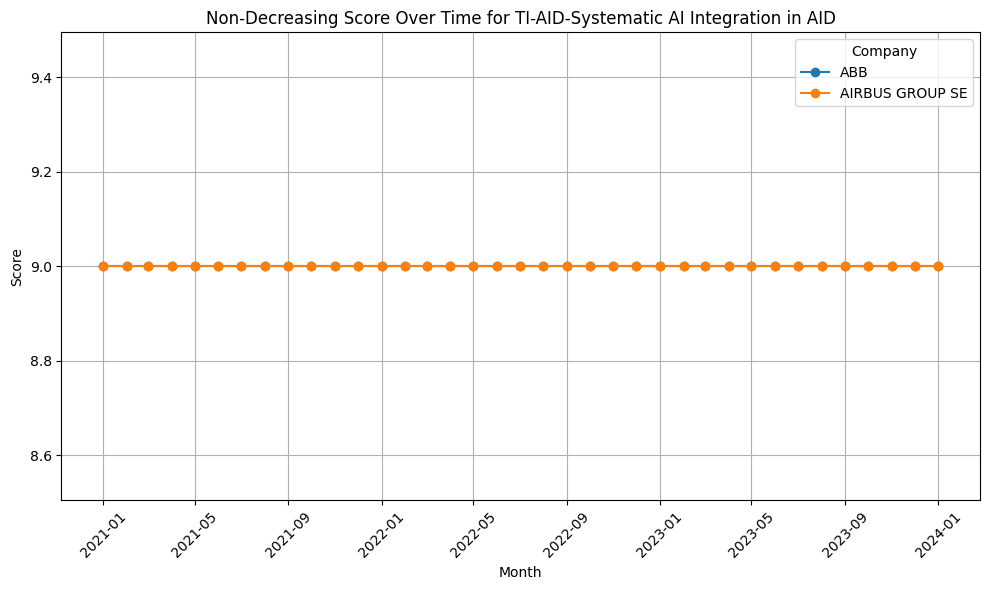

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data frame (assuming 'merged_df' is already loaded)
# merged_df = pd.read_csv('path_to_your_csv_file.csv')

def plot_non_decreasing_scores(df, company1, company2, capability):
    # Filter the DataFrame for the two companies and the specified capability
    filtered_df_BM = df[(df['Company Name Full'].isin([company1, company2])) & (df['capability'] == capability)]
    
    # Pivot the data for plotting with practices
    pivot_df_BM = filtered_df_BM.pivot_table(index=['month', 'practice'], columns='Company Name Full', values='score', aggfunc='mean').unstack('practice')
    
    # Get unique practices
    unique_practices = filtered_df_BM['practice'].unique()
    
    # Create a plot for each practice
    for practice in unique_practices:
        plt.figure(figsize=(10, 6))
        practice_data = pivot_df_BM.xs(practice, level='practice', axis=1)  # Data for the current practice
        
        # 🔥 Convert 'month' from PeriodIndex to DatetimeIndex for plotting
        practice_data.index = practice_data.index.to_timestamp()

        # Ensure scores do not decrease
        practice_data = practice_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company
        for company in [company1, company2]:
            if company in practice_data.columns:
                plt.plot(practice_data.index, practice_data[company], marker='o', label=f'{company}')
        
        plt.title(f'Non-Decreasing Score Over Time for {practice} in {capability}')
        plt.xlabel('Month')
        plt.ylabel('Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_non_decreasing_scores(merged_df, 'ABB', 'AIRBUS GROUP SE', 'AID')

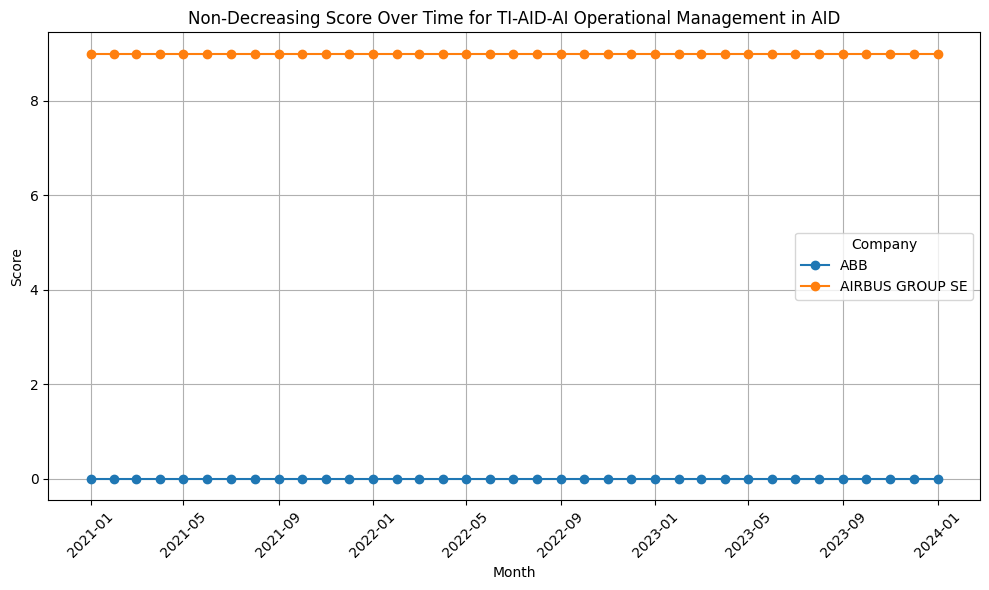

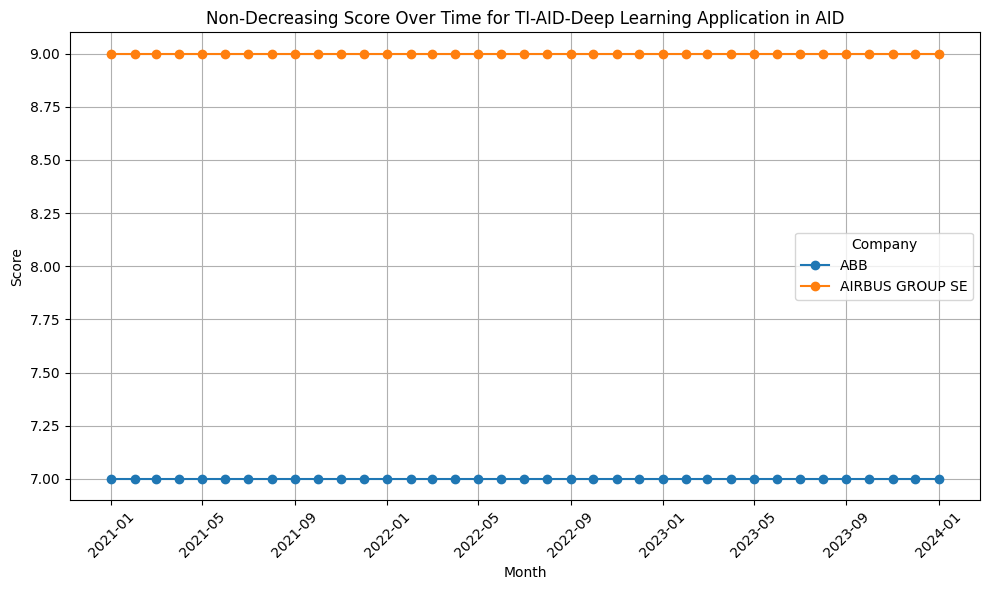

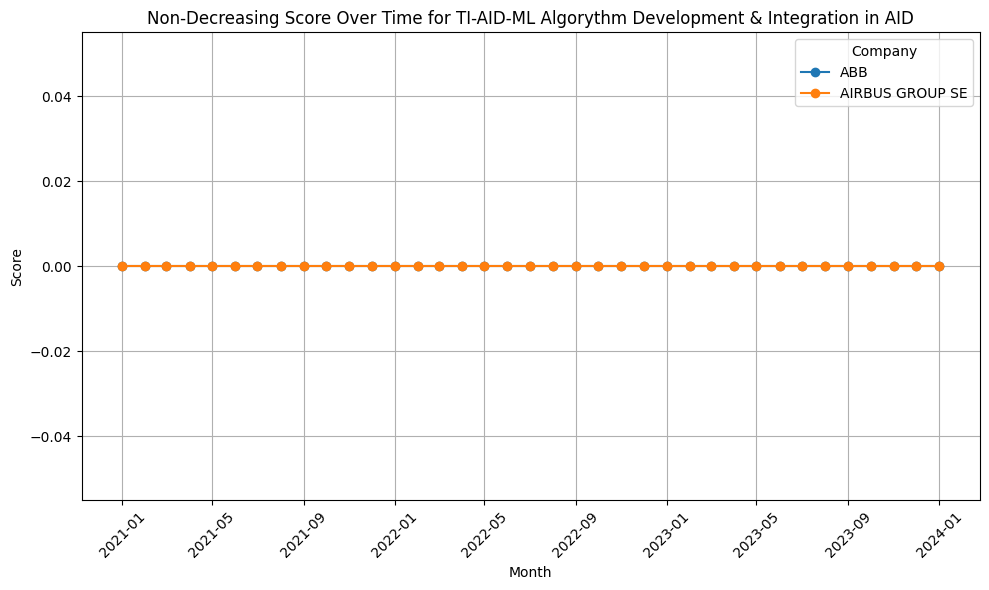

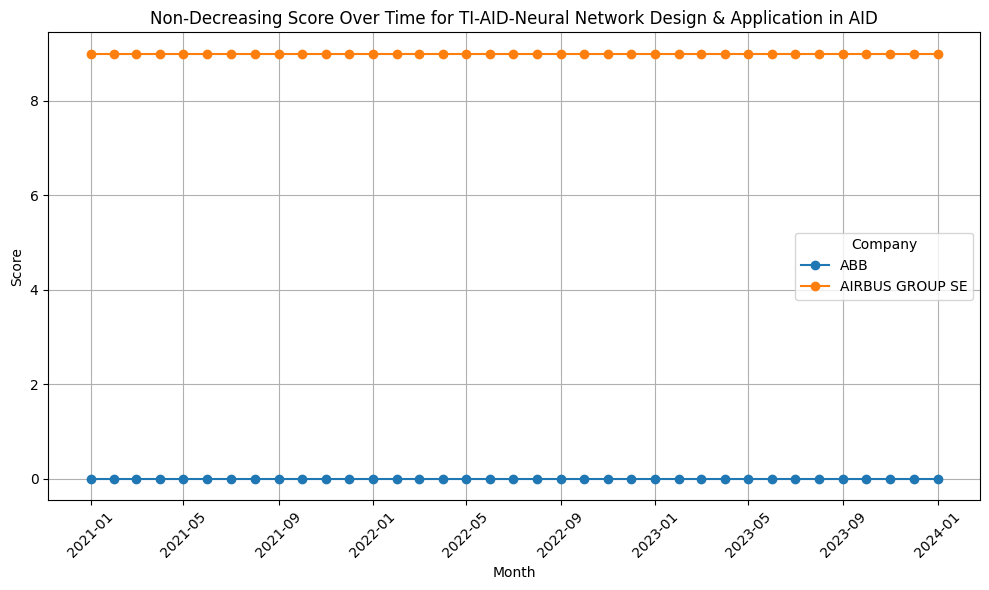

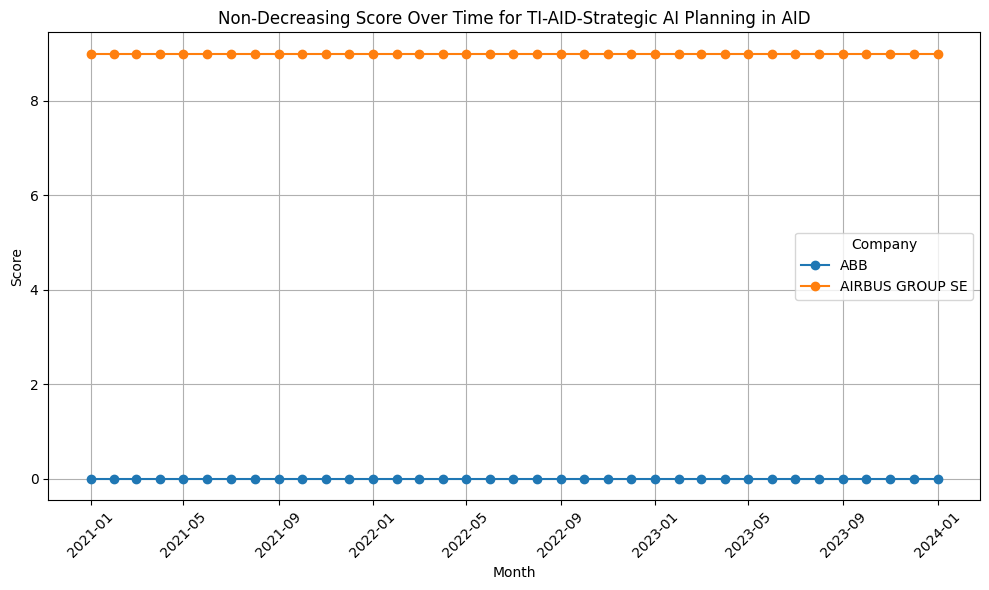

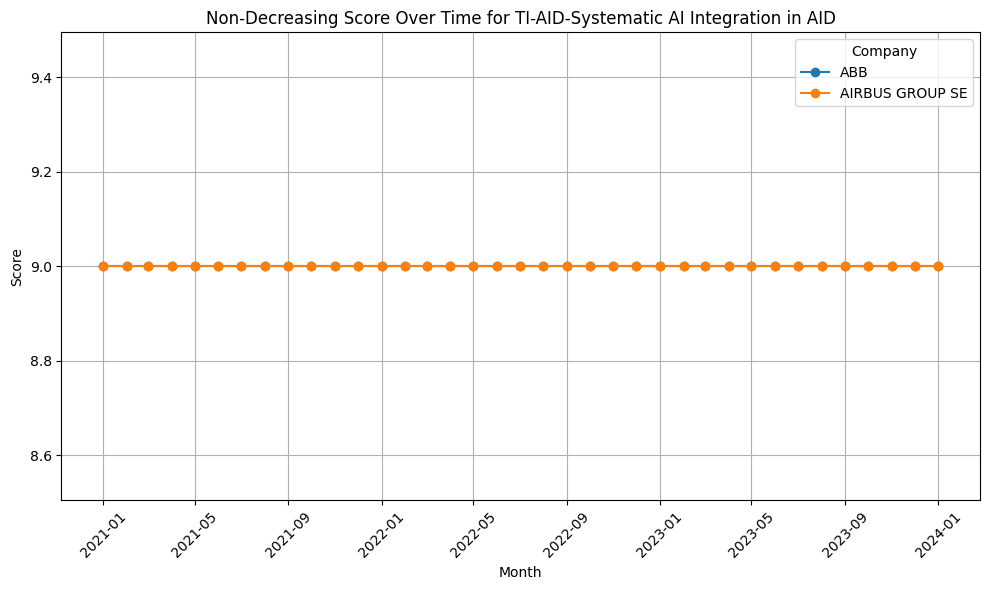

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_non_decreasing_scores(df, company1, company2, capability):
    # Filter the DataFrame for the two companies and the specified capability
    filtered_df_BM = df[(df['Company Name Full'].isin([company1, company2])) & (df['capability'] == capability)]
    
    # Pivot the data for plotting with practices
    pivot_df_BM = filtered_df_BM.pivot_table(index=['month', 'practice'], columns='Company Name Full', values='score', aggfunc='mean').unstack('practice')

    # Convert 'month' index from Period to Timestamp for plotting
    pivot_df_BM.index = pivot_df_BM.index.to_timestamp()
    
    # Get unique practices
    unique_practices = filtered_df_BM['practice'].unique()
    
    # Create a plot for each practice
    for practice in unique_practices:
        plt.figure(figsize=(10, 6))
        practice_data = pivot_df_BM.xs(practice, level='practice', axis=1)  # Data for the current practice
        
        # Ensure scores do not decrease
        practice_data = practice_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company
        for company in [company1, company2]:
            if company in practice_data.columns:
                plt.plot(practice_data.index, practice_data[company], marker='o', label=f'{company}')
        
        plt.title(f'Non-Decreasing Score Over Time for {practice} in {capability}')
        plt.xlabel('Month')
        plt.ylabel('Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_non_decreasing_scores(merged_df, 'ABB', 'AIRBUS GROUP SE', 'AID')

In [35]:
print(merged_df["score"].max())

9


Testing Benchmarking

In [42]:
# Calculate the maximum possible score for each capability
max_scores_per_capability = merged_df.groupby('capability').agg({'practice': 'nunique'}).reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# Sum the scores for each company, capability, supersector, pillar, and month
capability_scores = merged_df.groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'month'])['score'].sum().reset_index()

# Rename the 'score' column to 'maturity_score' for clarity
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# Merge the maximum scores for each capability back into the capability_scores DataFrame
final_scores2 = pd.merge(capability_scores, max_scores_per_capability[['capability', 'max_score_per_capability']], on='capability', how='left')

# Select relevant columns for display
final_scores2 = final_scores2[['Company Name Full', 'capability', 'Supersector', 'pillar', 'month', 'maturity_score', 'max_score_per_capability']]

final_scores2.head()




,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,3I GRP,AID,Financial Services,TI,2021-01,0,60
1,3I GRP,AID,Financial Services,TI,2021-02,0,60
2,3I GRP,AID,Financial Services,TI,2021-03,0,60
3,3I GRP,AID,Financial Services,TI,2021-04,0,60
4,3I GRP,AID,Financial Services,TI,2021-05,0,60


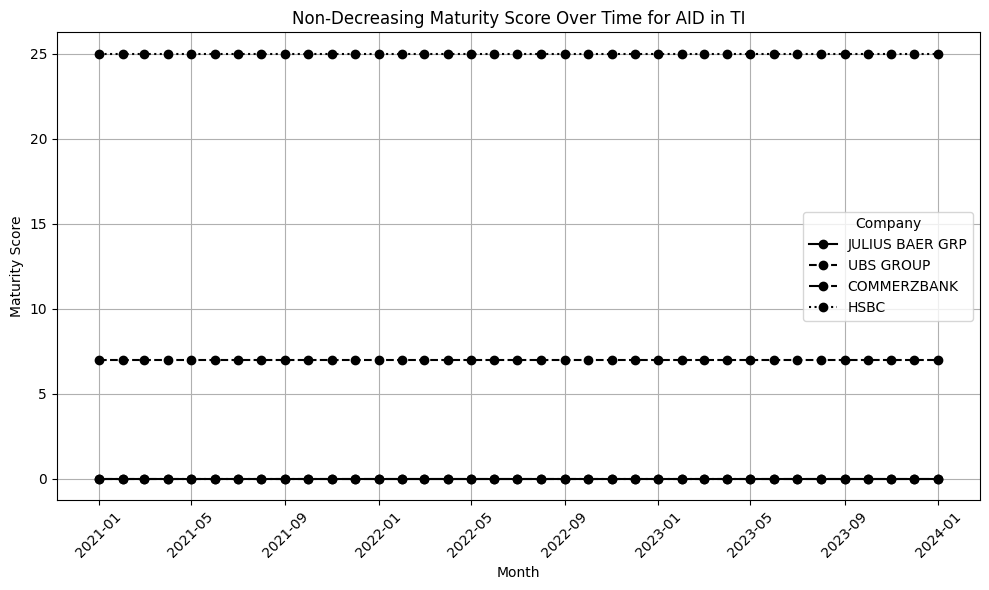

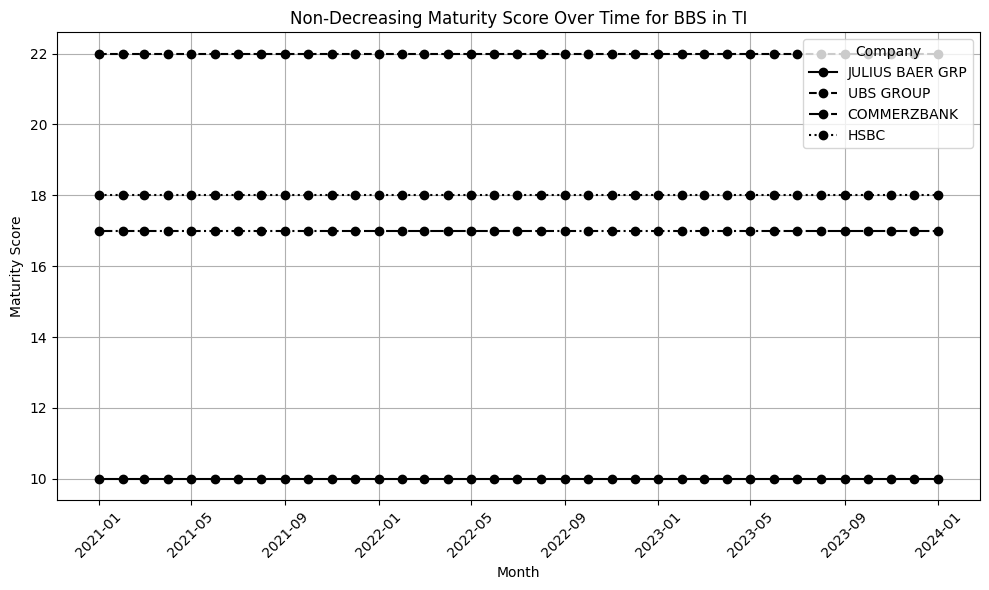

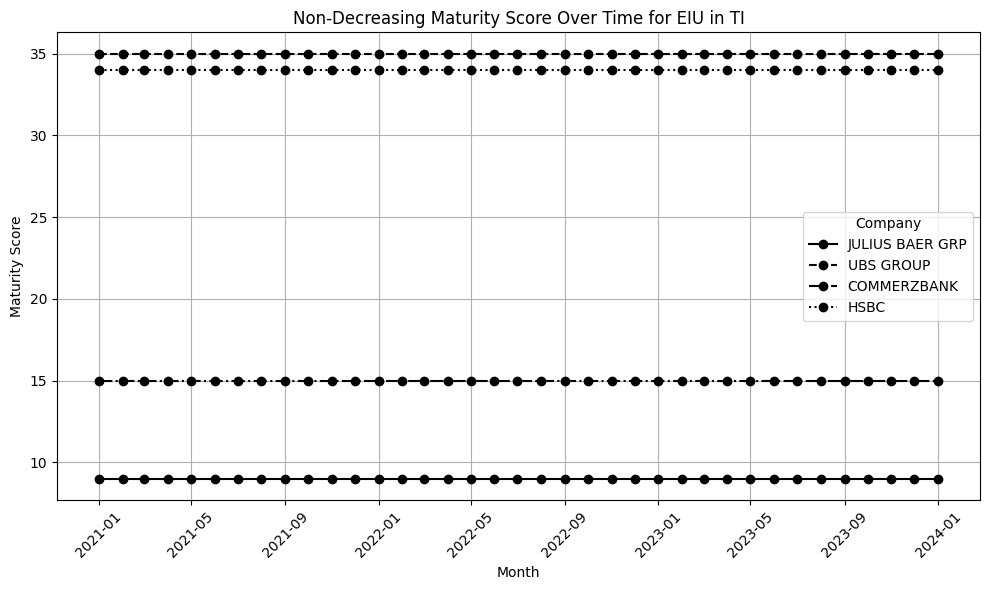

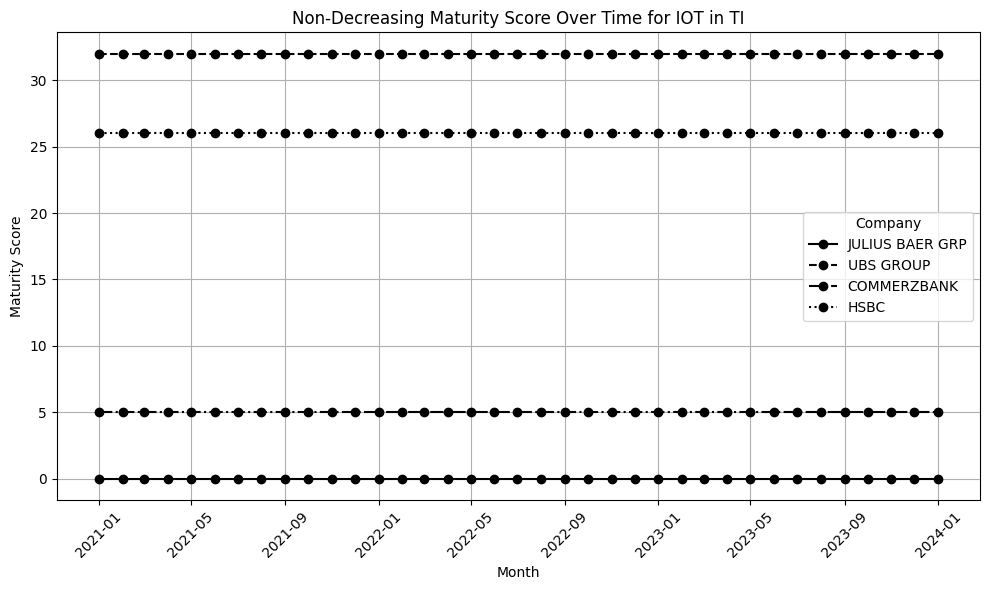

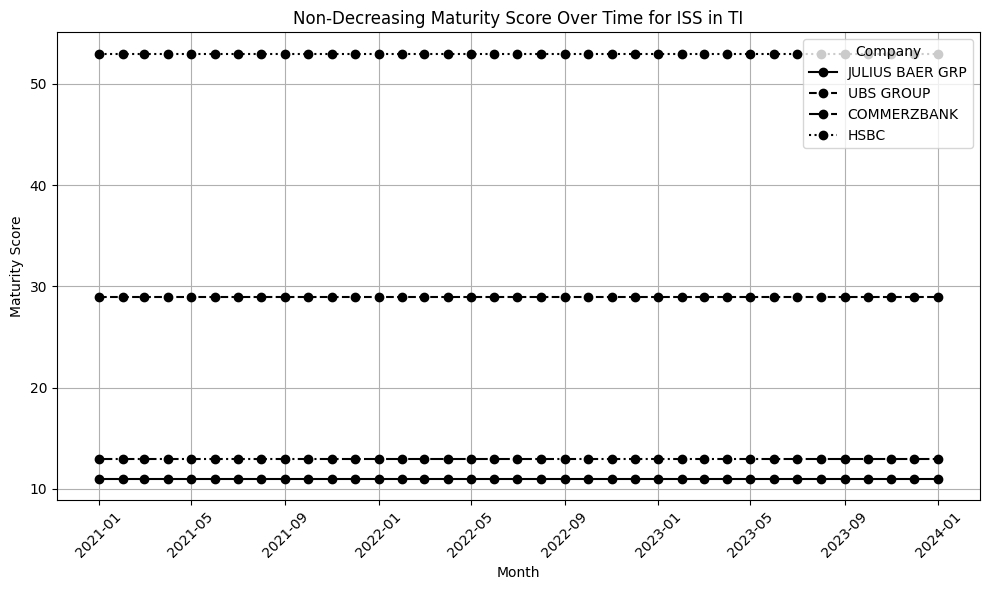

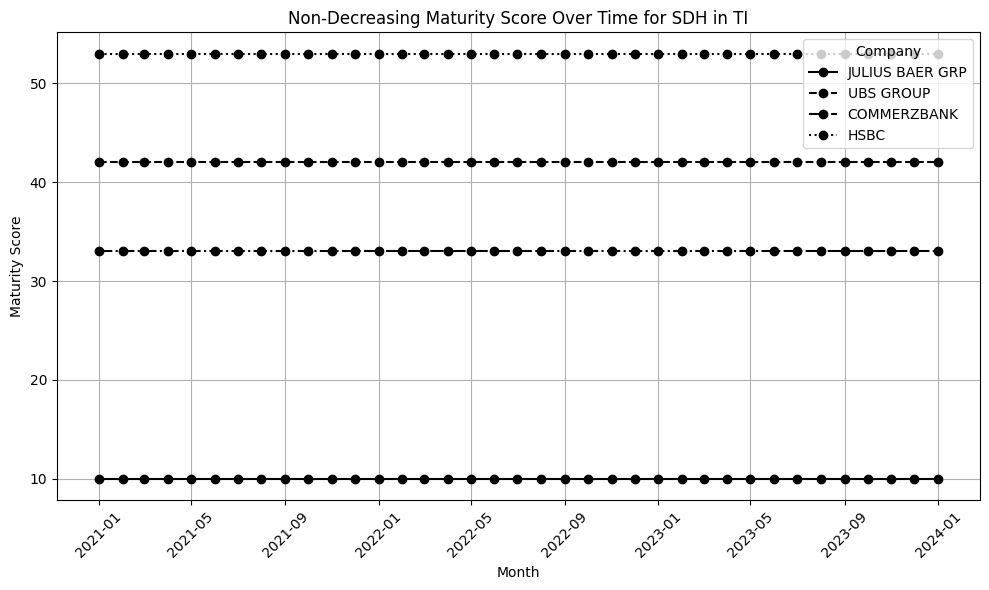

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_capability_scores(df, companies, pillar):
    # Filter the DataFrame for the specified companies and pillar
    filtered_df_BM2 = df[(df['Company Name Full'].isin(companies)) & (df['pillar'] == pillar)]
    
    # Pivot the data for plotting with capabilities
    pivot_df_BM2 = filtered_df_BM2.pivot_table(index=['month', 'capability'], columns='Company Name Full', values='maturity_score', aggfunc='mean').unstack('capability')
    
    # Convert 'month' index from PeriodIndex to DatetimeIndex
    pivot_df_BM2.index = pivot_df_BM2.index.to_timestamp()

    # Get unique capabilities
    unique_capabilities = filtered_df_BM2['capability'].unique()
    
    # Define line styles for the companies
    line_styles = ['-', '--', '-.', ':']
    
    # Ensure there are enough line styles for the number of companies
    line_styles = (line_styles * (len(companies) // len(line_styles) + 1))[:len(companies)]

    # Create a plot for each capability
    for capability in unique_capabilities:
        plt.figure(figsize=(10, 6))
        capability_data = pivot_df_BM2.xs(capability, level='capability', axis=1)  # Data for the current capability
        
        # Apply cumulative max to ensure scores do not decrease
        capability_data = capability_data.cummax()

        

        # Plot lines for each company with the same color but different line styles
        for idx, company in enumerate(companies):
            if company in capability_data.columns:
                plt.plot(capability_data.index, capability_data[company], marker='o', label=f'{company}', color='black', linestyle=line_styles[idx])
        
        plt.title(f'Non-Decreasing Maturity Score Over Time for {capability} in {pillar}')
        plt.xlabel('Month')
        plt.ylabel('Maturity Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_capability_scores(final_scores, ['JULIUS BAER GRP', 'UBS GROUP', 'COMMERZBANK', 'HSBC'], 'TI')

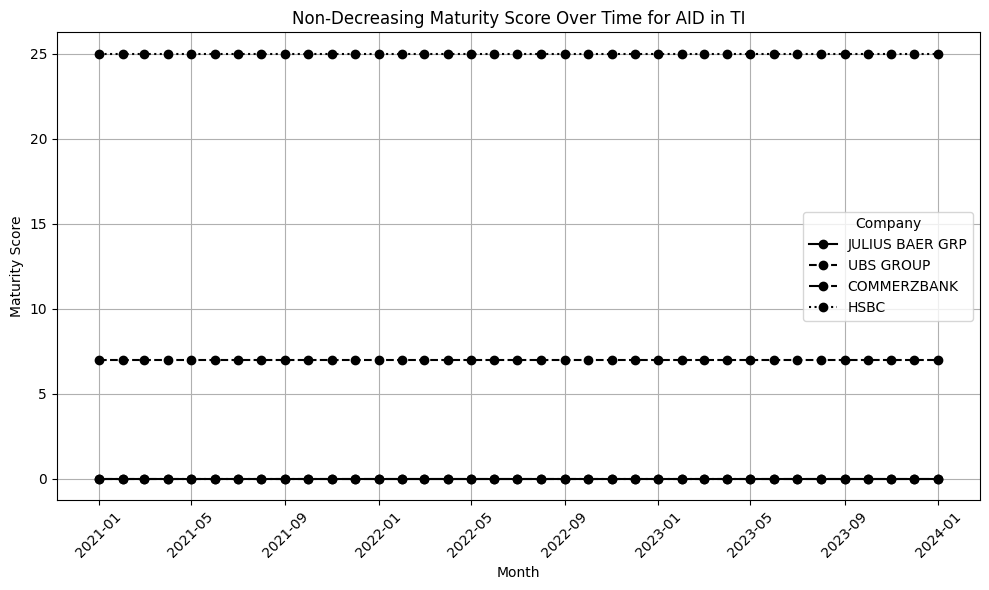

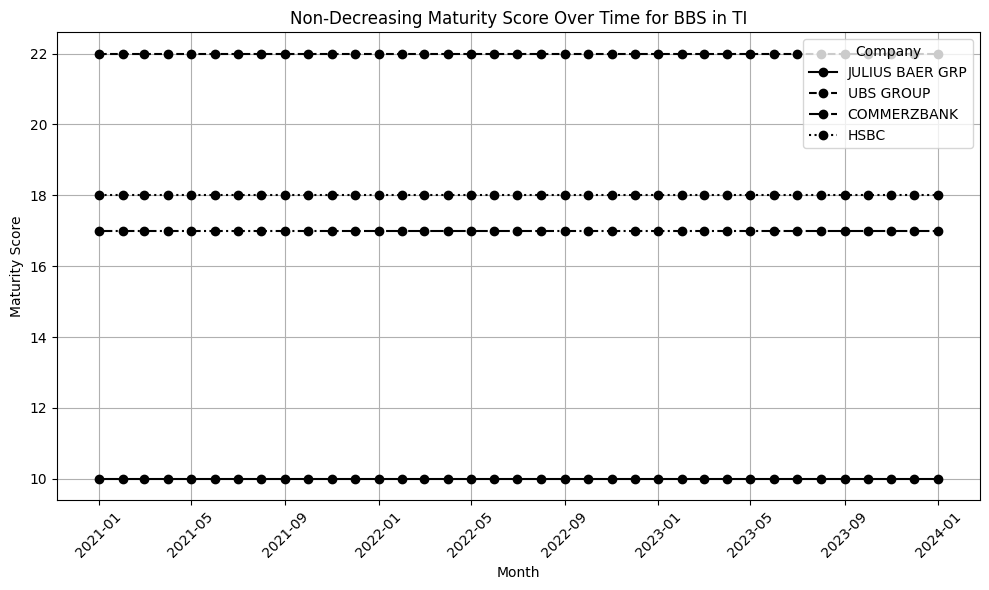

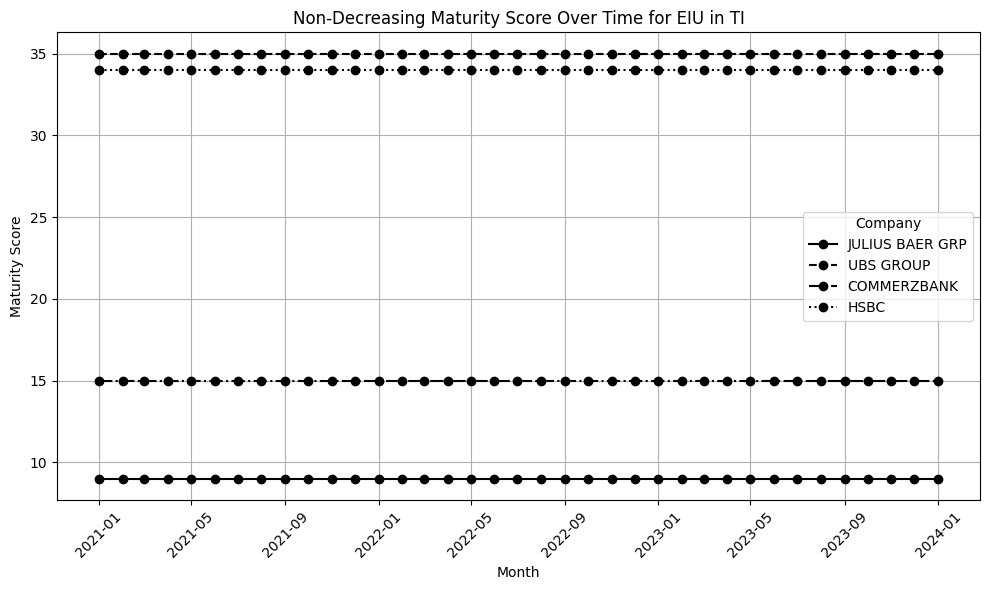

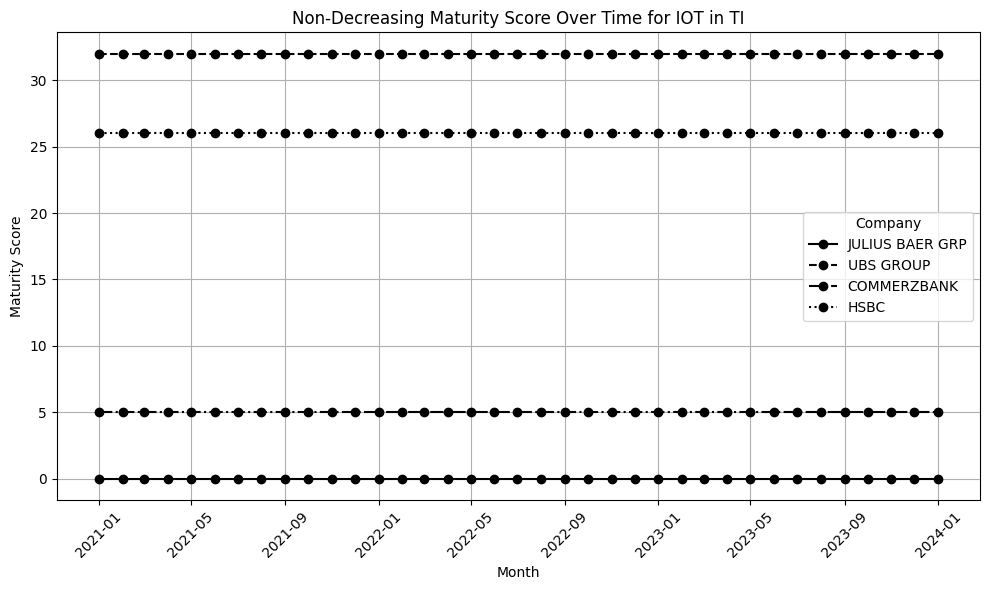

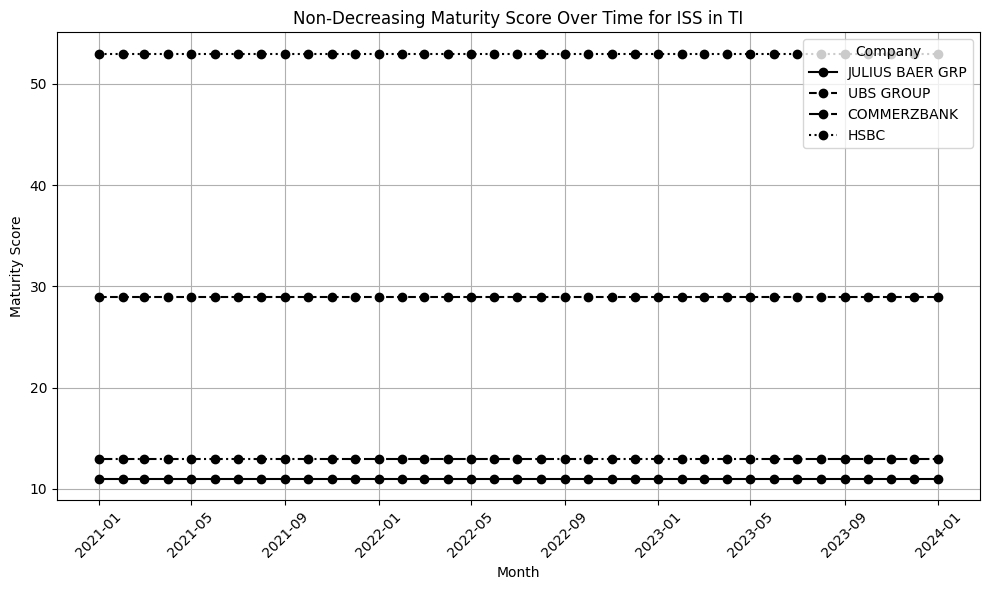

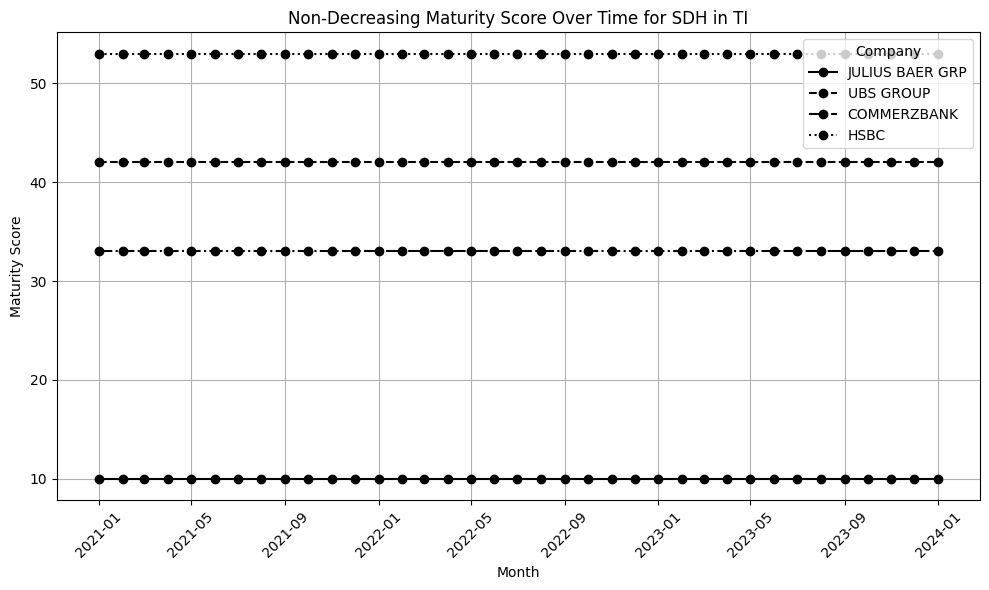

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data frame (assuming 'final_scores' is already loaded)
# final_scores = pd.read_csv('path_to_your_csv_file.csv')

def plot_capability_scores(df, companies, pillar):
    # Filter the DataFrame for the specified companies and pillar
    filtered_df_BM2 = df[(df['Company Name Full'].isin(companies)) & (df['pillar'] == pillar)]
    
    # Pivot the data for plotting with capabilities
    pivot_df_BM2 = filtered_df_BM2.pivot_table(index=['month', 'capability'], columns='Company Name Full', values='maturity_score', aggfunc='mean').unstack('capability')
    
    # Get unique capabilities
    unique_capabilities = filtered_df_BM2['capability'].unique()
    
    # Define line styles for the companies
    line_styles = ['-', '--', '-.', ':']
    
    # Ensure there are enough line styles for the number of companies
    line_styles = (line_styles * (len(companies) // len(line_styles) + 1))[:len(companies)]

    # Create a plot for each capability
    for capability in unique_capabilities:
        plt.figure(figsize=(10, 6))
        capability_data = pivot_df_BM2.xs(capability, level='capability', axis=1)  # Data for the current capability
        
        # Apply cumulative max to ensure scores do not decrease
        capability_data = capability_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company with the same color but different line styles
        for idx, company in enumerate(companies):
            if company in capability_data.columns:
                plt.plot(capability_data.index, capability_data[company], marker='o', label=f'{company}', color='black', linestyle=line_styles[idx])
        
        plt.title(f'Non-Decreasing Maturity Score Over Time for {capability} in {pillar}')
        plt.xlabel('Month')
        plt.ylabel('Maturity Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_capability_scores(final_scores, ['JULIUS BAER GRP', 'UBS GROUP', 'COMMERZBANK', 'HSBC'], 'TI')


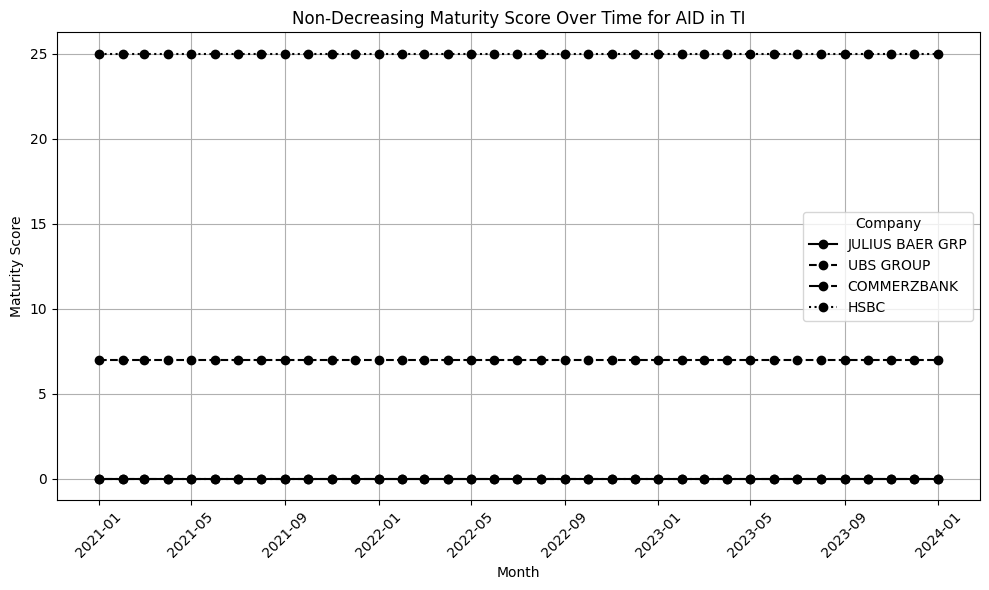

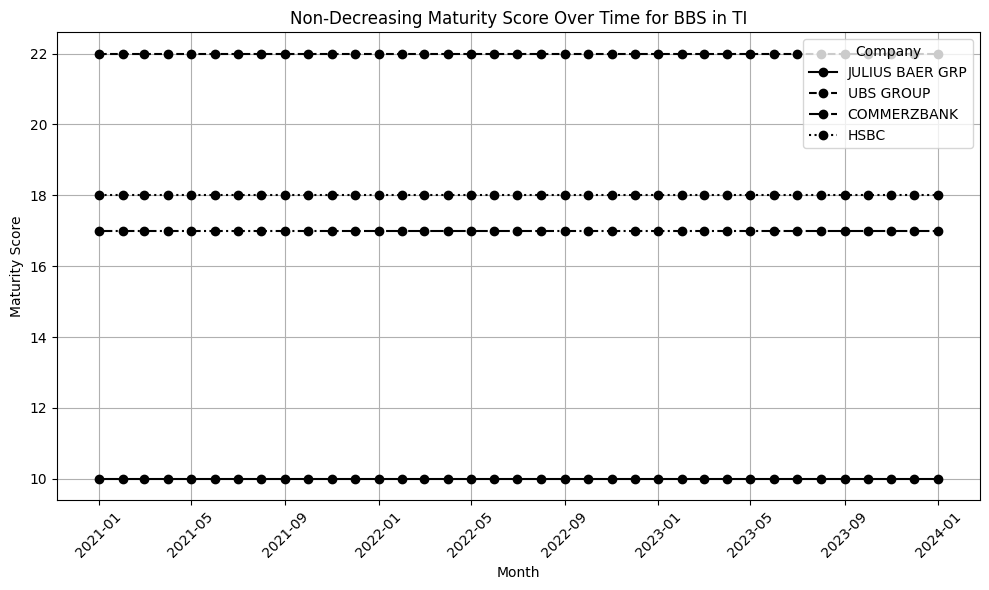

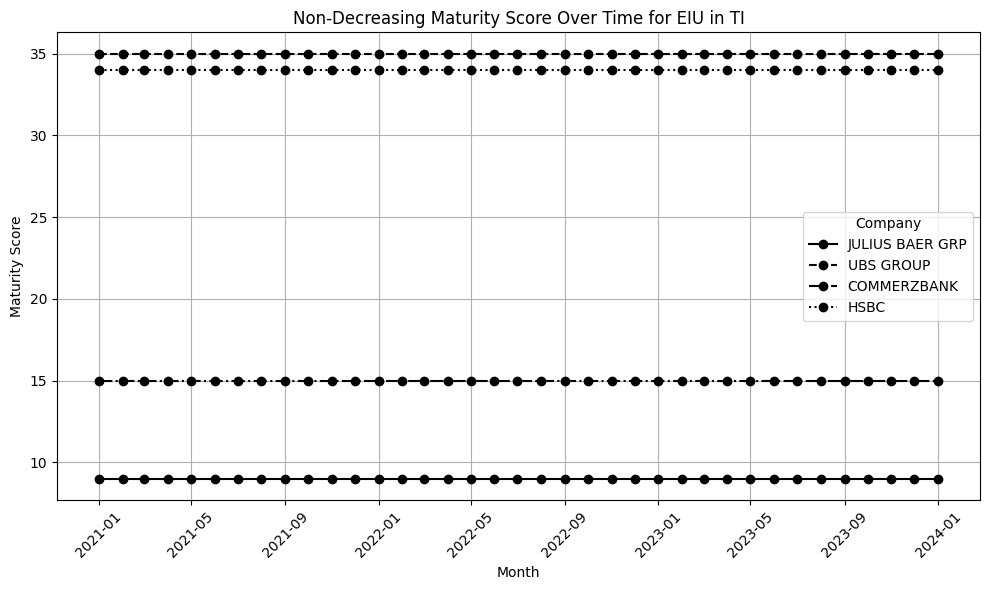

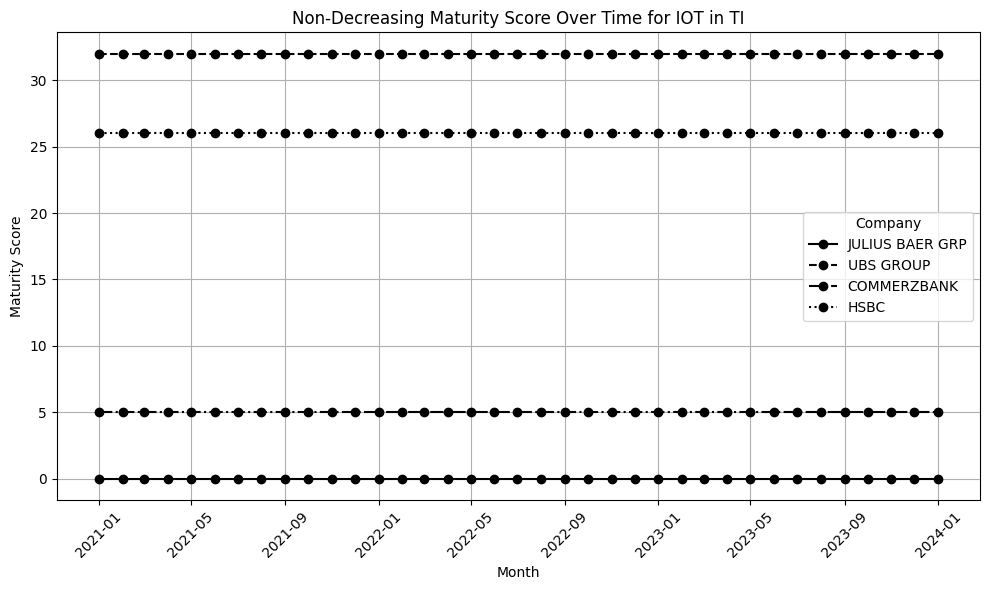

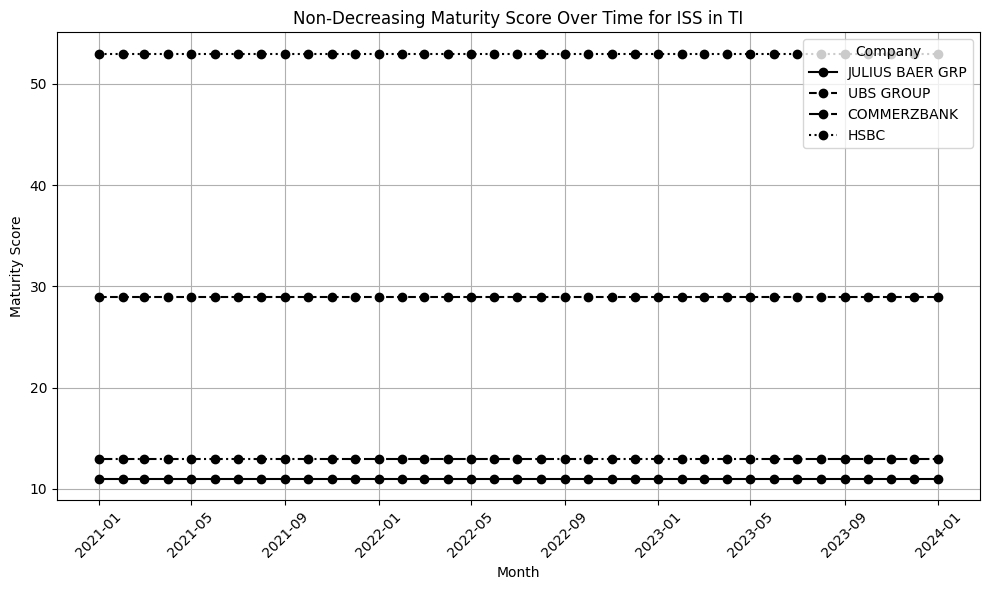

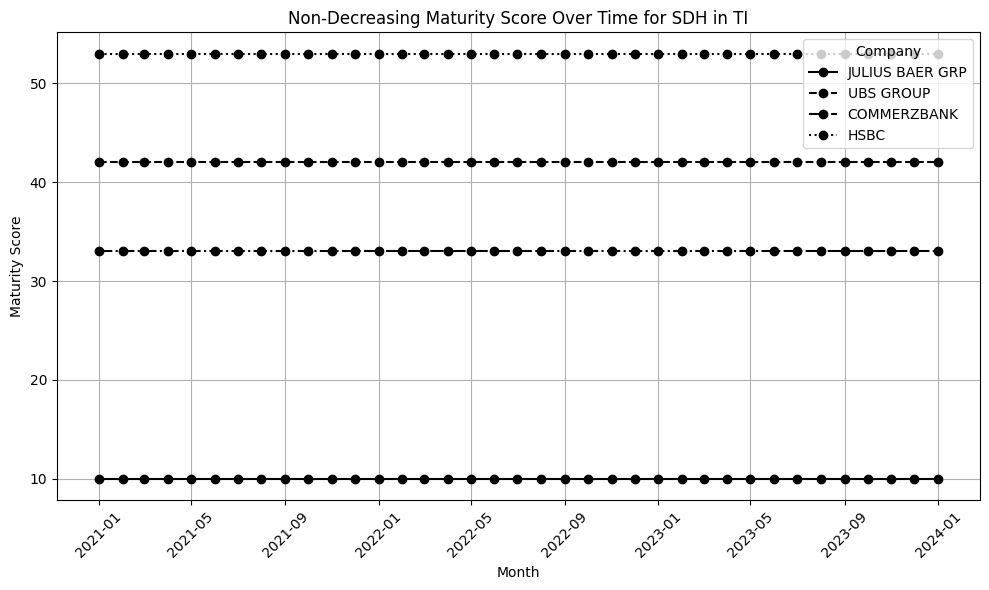

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Funktion zur Visualisierung der Capability-Scores
def plot_capability_scores(df, companies, pillar):
    # Filtere den DataFrame für die angegebenen Unternehmen und die Säule
    filtered_df_BM2 = df[(df['Company Name Full'].isin(companies)) & (df['pillar'] == pillar)]
    
    # Pivot-Tabelle für die Visualisierung erstellen
    pivot_df_BM2 = filtered_df_BM2.pivot_table(
        index=['month', 'capability'], 
        columns='Company Name Full', 
        values='maturity_score', 
        aggfunc='mean'
    ).unstack('capability')
    
    # Konvertiere den 'month'-Index von Period zu Datetime für die Visualisierung
    pivot_df_BM2.index = pivot_df_BM2.index.to_timestamp()
    
    # Einzigartige Capabilities extrahieren
    unique_capabilities = filtered_df_BM2['capability'].unique()
    
    # Definiere verschiedene Linienstile für die Unternehmen
    line_styles = ['-', '--', '-.', ':']
    
    # Stelle sicher, dass genügend Linienstile für die Anzahl der Unternehmen vorhanden sind
    line_styles = (line_styles * (len(companies) // len(line_styles) + 1))[:len(companies)]

    # Erstelle ein Diagramm für jede Capability
    for capability in unique_capabilities:
        plt.figure(figsize=(10, 6))
        capability_data = pivot_df_BM2.xs(capability, level='capability', axis=1)  # Daten für die aktuelle Capability
        
        # Wende cumulative max an, um sicherzustellen, dass die Scores nicht abnehmen
        capability_data = capability_data.cummax()
        
        # Zeichne Linien für jedes Unternehmen mit demselben Stil, aber unterschiedlichen Linienstilen
        for idx, company in enumerate(companies):
            if company in capability_data.columns:
                plt.plot(
                    capability_data.index, 
                    capability_data[company], 
                    marker='o', 
                    label=f'{company}', 
                    color='black', 
                    linestyle=line_styles[idx]
                )
        
        # Diagrammtitel und Achsenbeschriftungen hinzufügen
        plt.title(f'Non-Decreasing Maturity Score Over Time for {capability} in {pillar}')
        plt.xlabel('Month')
        plt.ylabel('Maturity Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Drehung der Monatsbeschriftungen für bessere Lesbarkeit
        plt.tight_layout()
        plt.show()

# Beispielaufruf der Funktion
plot_capability_scores(final_scores2, ['JULIUS BAER GRP', 'UBS GROUP', 'COMMERZBANK', 'HSBC'], 'TI')